# OD/OC Segmentation — Train & Evaluate: U-Net

Single architecture (**unet**), manifest-driven. Reads the team's
`combined_segmentation_manifest_with_splits.csv`, trains on the bundle
(ORIGA + G1020 + REFUGE) train split, and shows per-image generalization on the
bundle test split. PAPILA is held out as the clinical transfer target and is not
trained on here. Runs on CUDA / Apple MPS / CPU (auto-detected).

Run each model's notebook across 3 seeds (41, 42, 43).

## 1. Config

In [32]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [33]:
MODEL_NAME = "unet"
SEED = 43
EPOCHS = 40
BATCH_SIZE = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 512
NUM_CLASSES = 3                 # 0=background, 1=disc, 2=cup
ENCODER_WEIGHTS = "imagenet"    # None to skip pretrained download (offline)
SCHEDULER = "cosine"
WARMUP_EPOCHS = 2
EARLY_STOP_PATIENCE = 8
USE_AMP = True
NUM_WORKERS = 0
OUTPUT_DIR = "runs"             # under project root

MANIFEST_REL = "data/processed/manifests/combined_segmentation_manifest_with_splits.csv"
TRAIN_SOURCES = ["ORIGA", "G1020", "REFUGE"]   # bundle pool; PAPILA held out for transfer
SAVE_ALL_PREDS = True

In [34]:
import os, math, random, time, json, csv
from contextlib import nullcontext
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

def find_project_root(start_path=None):
    start_path = start_path or Path.cwd()
    for path in [start_path, *start_path.parents]:
        if (path / "configs").exists() and (path / "src").exists():
            return path
    return Path.cwd()   # fall back to cwd if the repo markers aren't found

PROJECT_ROOT = find_project_root()
CLASS_NAMES = ["background", "disc", "cup"]
RUN_TAG = f"{MODEL_NAME}_seed{SEED}"
RUN_DIR = PROJECT_ROOT / OUTPUT_DIR / RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("project root:", PROJECT_ROOT)

project root: /Users/tylerhobbs/Documents/Virginia/Glaucoma Project


## 2. Device + AMP (AMP only on CUDA)

In [35]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
amp_on = USE_AMP and device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=amp_on) if amp_on else None

def autocast_ctx():
    return torch.autocast("cuda", dtype=torch.float16) if amp_on else nullcontext()

print(f"device={device.type}  amp={amp_on}  run={RUN_TAG}")

device=mps  amp=False  run=unet_seed43


## 3. Seeding

In [36]:
def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

## 4. Model

In [ ]:
MODEL_REGISTRY = {
    "deeplabv3plus": ("DeepLabV3Plus", "resnet50"),
    "unet":          ("Unet",          "resnet50"),
    "unetplusplus":  ("UnetPlusPlus",  "resnet50"),
}

def build_model(name, num_classes=NUM_CLASSES, encoder_weights=ENCODER_WEIGHTS):
    cls_name, encoder = MODEL_REGISTRY[name]
    return getattr(smp, cls_name)(encoder_name=encoder, encoder_weights=encoder_weights,
                                  in_channels=3, classes=num_classes)

## 5. Loss — Dice + Cross-Entropy

In [38]:
class DiceCELoss(nn.Module):
    def __init__(self, dice_w=1.0, ce_w=1.0):
        super().__init__()
        self.dice_w, self.ce_w = dice_w, ce_w
        self.dice = smp.losses.DiceLoss(mode="multiclass")
        self.ce = nn.CrossEntropyLoss()
    def forward(self, logits, target):
        return self.dice_w * self.dice(logits, target) + self.ce_w * self.ce(logits, target)

## 6. Metrics — per-class Dice/IoU + vertical CDR

In [39]:
class SegMetrics:
    def __init__(self, num_classes=NUM_CLASSES):
        self.n = num_classes
        self.inter = torch.zeros(num_classes)
        self.pred = torch.zeros(num_classes)
        self.tgt = torch.zeros(num_classes)
    @torch.no_grad()
    def update(self, logits, target):
        pred = logits.argmax(1)
        for c in range(self.n):
            p, t = (pred == c), (target == c)
            self.inter[c] += (p & t).sum().item()
            self.pred[c] += p.sum().item()
            self.tgt[c] += t.sum().item()
    def compute(self):
        eps = 1e-7
        dice = 2 * self.inter / (self.pred + self.tgt + eps)
        iou = self.inter / (self.pred + self.tgt - self.inter + eps)
        out = {}
        for c in range(self.n):
            out[f"dice_{CLASS_NAMES[c]}"] = dice[c].item()
            out[f"iou_{CLASS_NAMES[c]}"] = iou[c].item()
        out["dice_mean_fg"] = dice[1:].mean().item()
        return out

def vertical_cdr_from_mask(mask):
    disc_rows = np.where((mask >= 1).any(axis=1))[0]
    if disc_rows.size == 0:
        return np.nan
    disc_h = disc_rows.max() - disc_rows.min() + 1
    cup_rows = np.where((mask == 2).any(axis=1))[0]
    cup_h = (cup_rows.max() - cup_rows.min() + 1) if cup_rows.size else 0
    return cup_h / disc_h

def dice_one(pred, tgt, c):
    p, t = (pred == c), (tgt == c)
    s = p.sum() + t.sum()
    return float(2 * (p & t).sum() / s) if s > 0 else float("nan")

## 7. Data — read the combined manifest, filter by source + split

Image/mask paths come straight from the manifest (project-relative); masks are
already `{0,1,2}`. No folder scanning, no re-splitting — the splits are exactly
the ones produced by `04_split_strategy_all_sources.ipynb`.

In [40]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def denormalize(t):
    img = t.cpu().numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

def load_split(split):
    df = pd.read_csv(PROJECT_ROOT / MANIFEST_REL)
    df = df[(df["source_dataset"].isin(TRAIN_SOURCES)) & (df["split"] == split)]
    return df.reset_index(drop=True)

class GlaucomaDataset(Dataset):
    def __init__(self, df, size=IMG_SIZE):
        self.df = df.reset_index(drop=True)
        self.size = size
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(PROJECT_ROOT / r["image_path"]).convert("RGB").resize((self.size, self.size), Image.BILINEAR)
        msk = Image.open(PROJECT_ROOT / r["mask_path"]).resize((self.size, self.size), Image.NEAREST)
        img = (np.asarray(img, np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
        img = torch.from_numpy(img.transpose(2, 0, 1)).float()
        msk = np.asarray(msk)
        if msk.ndim == 3:
            msk = msk[..., 0]
        return img, torch.from_numpy(msk.astype(np.int64))

train_df, val_df, test_df = load_split("train"), load_split("val"), load_split("test")
print(f"data (sources={TRAIN_SOURCES}): train={len(train_df)} val={len(val_df)} test={len(test_df)}")
pin = device.type == "cuda"
train_ld = DataLoader(GlaucomaDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=pin, drop_last=True)
val_ld = DataLoader(GlaucomaDataset(val_df), batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=pin)

data (sources=['ORIGA', 'G1020', 'REFUGE']): train=1569 val=650 test=651


## 8. Optimizer + schedule

In [41]:
def make_scheduler(optimizer, epochs, steps):
    total, warmup = epochs * steps, WARMUP_EPOCHS * steps
    def lr_lambda(step):
        if step < warmup:
            return step / max(1, warmup)
        prog = (step - warmup) / max(1, total - warmup)
        return (1 - prog) ** 0.9 if SCHEDULER == "poly" else 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

## 9. Train / validate

In [42]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    running = 0.0
    for img, mask in loader:
        img, mask = img.to(device), mask.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast_ctx():
            loss = criterion(model(img), mask)
        if scaler:
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            loss.backward(); optimizer.step()
        scheduler.step()
        running += loss.item() * img.size(0)
    return running / len(loader.dataset)

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running, metrics = 0.0, SegMetrics()
    for img, mask in loader:
        img, mask = img.to(device), mask.to(device)
        logits = model(img)
        running += criterion(logits, mask).item() * img.size(0)
        metrics.update(logits, mask)
    out = metrics.compute()
    out["loss"] = running / len(loader.dataset)
    return out

## 10. Run training (early stop on val Dice, save best)

In [43]:
model = build_model(MODEL_NAME).to(device)
criterion = DiceCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = make_scheduler(optimizer, EPOCHS, len(train_ld))

best_dice, best_epoch, since = -1.0, -1, 0
ckpt_path = RUN_DIR / "best.pt"
history = []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = train_one_epoch(model, train_ld, criterion, optimizer, scheduler)
    val = validate(model, val_ld, criterion)
    history.append({"epoch": epoch, "train_loss": tr, **val})
    print(f"epoch {epoch:02d} | train {tr:.4f} | val {val['loss']:.4f} "
          f"| Dice disc {val['dice_disc']:.3f} cup {val['dice_cup']:.3f} | {time.time()-t0:.1f}s")
    if val["dice_mean_fg"] > best_dice:
        best_dice, best_epoch, since = val["dice_mean_fg"], epoch, 0
        torch.save({"model": model.state_dict(), "epoch": epoch, "val": val,
                    "config": {"model": MODEL_NAME, "seed": SEED}}, ckpt_path)
    else:
        since += 1
        if since >= EARLY_STOP_PATIENCE:
            print(f"early stop @ {epoch} (best {best_dice:.3f} @ {best_epoch})")
            break
json.dump(history, open(RUN_DIR / "history.json", "w"), indent=2)
print(f"\nbest mean-fg Dice {best_dice:.3f} @ epoch {best_epoch}")

epoch 01 | train 1.4484 | val 0.8881 | Dice disc 0.777 cup 0.781 | 191.1s
epoch 02 | train 0.5618 | val 0.3220 | Dice disc 0.839 cup 0.814 | 188.7s
epoch 03 | train 0.1987 | val 0.1977 | Dice disc 0.781 cup 0.776 | 188.6s
epoch 04 | train 0.1328 | val 0.1289 | Dice disc 0.860 cup 0.858 | 188.6s
epoch 05 | train 0.1107 | val 0.1283 | Dice disc 0.864 cup 0.832 | 188.5s
epoch 06 | train 0.1010 | val 0.1114 | Dice disc 0.873 cup 0.867 | 188.7s
epoch 07 | train 0.0947 | val 0.1146 | Dice disc 0.868 cup 0.857 | 189.6s
epoch 08 | train 0.0895 | val 0.1231 | Dice disc 0.856 cup 0.849 | 188.6s
epoch 09 | train 0.0828 | val 0.1129 | Dice disc 0.868 cup 0.860 | 189.2s
epoch 10 | train 0.0762 | val 0.1231 | Dice disc 0.853 cup 0.856 | 188.8s
epoch 11 | train 0.0747 | val 0.1296 | Dice disc 0.853 cup 0.834 | 188.5s
epoch 12 | train 0.0775 | val 0.1197 | Dice disc 0.852 cup 0.860 | 189.6s
epoch 13 | train 0.0661 | val 0.1269 | Dice disc 0.872 cup 0.813 | 189.4s
epoch 14 | train 0.0595 | val 0.1262 |

## 11. Generalization — per-image segmentation on the held-out test split

Per-image metrics CSV (Dice disc/cup, CDR predicted vs truth, tagged by source),
aggregate test scores, and an overlay PNG per test image with `SAVE_ALL_PREDS`.

In [44]:
cmap = np.array([[0, 0, 0], [0, 1, 0], [1, 0, 0]])  # disc=green, cup=red

def overlay_rgba(m):
    rgba = np.zeros((*m.shape, 4), np.float32)
    rgba[..., :3] = cmap[m]
    rgba[..., 3] = np.where(m > 0, 0.55, 0.0)
    return rgba

def save_overlay(path, rgb, gt, pr, title):
    fig, ax = plt.subplots(1, 3, figsize=(9, 3.2))
    ax[0].imshow(rgb); ax[0].set_title("image")
    ax[1].imshow(rgb); ax[1].imshow(overlay_rgba(gt)); ax[1].set_title("ground truth")
    ax[2].imshow(rgb); ax[2].imshow(overlay_rgba(pr)); ax[2].set_title(title)
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.savefig(path, dpi=100, bbox_inches="tight"); plt.close(fig)

@torch.no_grad()
def per_image_eval(model, df):
    model.eval()
    ds = GlaucomaDataset(df)
    preds_dir = RUN_DIR / "preds"
    if SAVE_ALL_PREDS:
        preds_dir.mkdir(exist_ok=True)
    rows = []
    for i in range(len(ds)):
        r = df.iloc[i]
        img, msk = ds[i]
        gt = msk.numpy()
        pr = model(img.unsqueeze(0).to(device)).argmax(1)[0].cpu().numpy()
        dd, dc = dice_one(pr, gt, 1), dice_one(pr, gt, 2)
        cdr_p, cdr_g = vertical_cdr_from_mask(pr), vertical_cdr_from_mask(gt)
        cdr_err = abs((0.0 if np.isnan(cdr_p) else cdr_p) - cdr_g) if not np.isnan(cdr_g) else np.nan
        rows.append({"file_id": r["file_id"], "source": r["source_dataset"],
                     "dice_disc": dd, "dice_cup": dc,
                     "cdr_pred": cdr_p, "cdr_gt": cdr_g, "cdr_err": cdr_err})
        if SAVE_ALL_PREDS:
            save_overlay(preds_dir / f"{r['source_dataset']}_{r['file_id']}.png",
                         denormalize(img), gt, pr,
                         f"pred (cup Dice {dc:.2f}, CDR {cdr_p:.2f}/{cdr_g:.2f})")
    pd.DataFrame(rows).to_csv(RUN_DIR / "per_image_metrics.csv", index=False)
    return rows

state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state["model"])
rows = per_image_eval(model, test_df)

def _m(key):
    vals = [r[key] for r in rows if not np.isnan(r[key])]
    return float(np.mean(vals)) if vals else float("nan")
print(f"TEST ({len(rows)} images) | Dice disc {_m('dice_disc'):.3f} "
      f"cup {_m('dice_cup'):.3f} | CDR MAE {_m('cdr_err'):.3f}")
print(f"per-image metrics CSV -> {RUN_DIR/'per_image_metrics.csv'}")

TEST (651 images) | Dice disc 0.874 cup 0.838 | CDR MAE 0.060
per-image metrics CSV -> /Users/tylerhobbs/Documents/Virginia/Glaucoma Project/runs/unet_seed43/per_image_metrics.csv


## 12. Gallery — worst and best test images by cup Dice

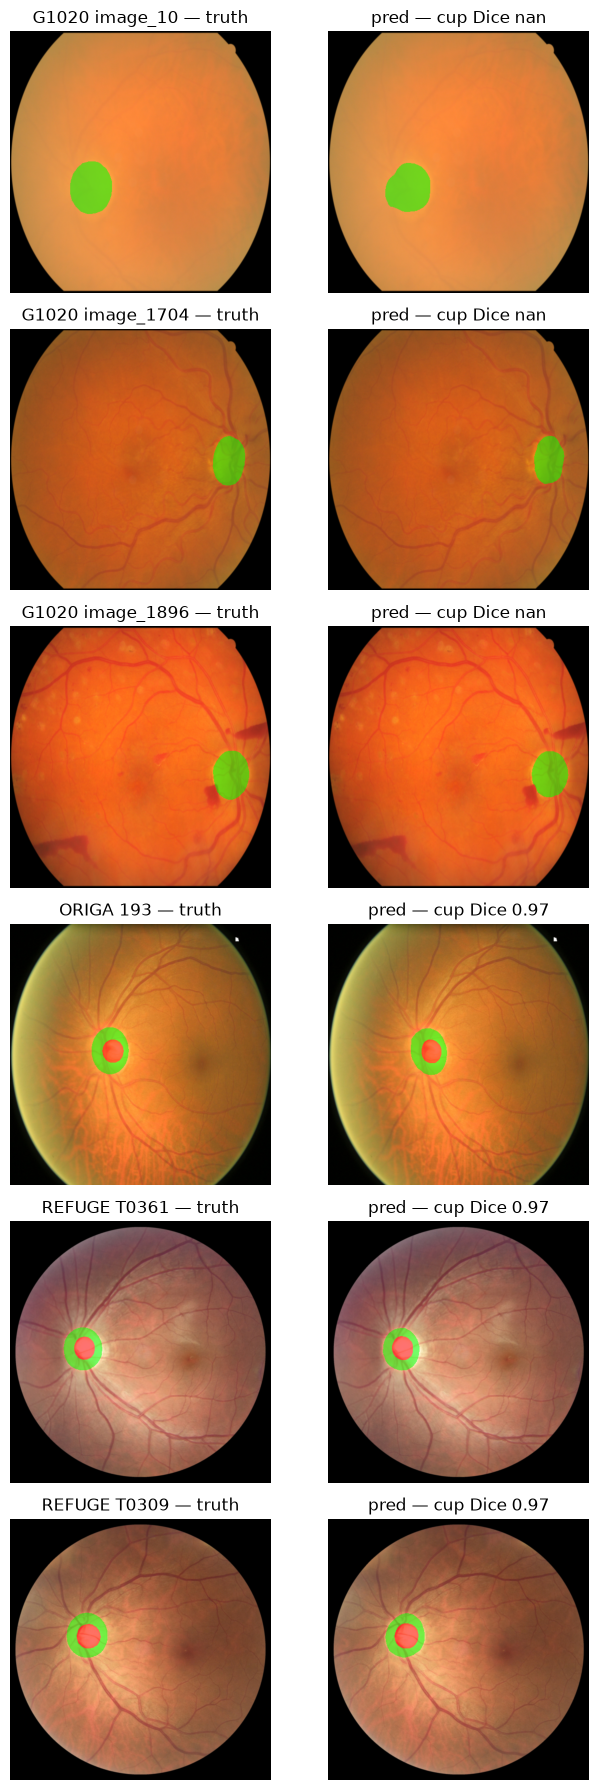

top rows = worst cup Dice, bottom = best — disc green, cup red


In [45]:
ds = GlaucomaDataset(test_df)
order = sorted(range(len(rows)), key=lambda i: np.nan_to_num(rows[i]["dice_cup"], nan=-1))
picks = order[:3] + order[-3:]
fig, ax = plt.subplots(len(picks), 2, figsize=(7, 3.0 * len(picks)))
for r, idx in enumerate(picks):
    img, msk = ds[idx]
    pr = model(img.unsqueeze(0).to(device)).argmax(1)[0].detach().cpu().numpy()
    rgb = denormalize(img)
    ax[r, 0].imshow(rgb); ax[r, 0].imshow(overlay_rgba(msk.numpy()))
    ax[r, 0].set_title(f"{rows[idx]['source']} {rows[idx]['file_id']} — truth")
    ax[r, 1].imshow(rgb); ax[r, 1].imshow(overlay_rgba(pr))
    ax[r, 1].set_title(f"pred — cup Dice {rows[idx]['dice_cup']:.2f}")
    ax[r, 0].axis("off"); ax[r, 1].axis("off")
plt.tight_layout()
plt.savefig(RUN_DIR / "gallery_best_worst.png", dpi=100, bbox_inches="tight")
plt.show()
print("top rows = worst cup Dice, bottom = best — disc green, cup red")